In [17]:
#ID3


In [18]:
# ID3 est un algorithme d’arbre de décision qui utilise l’entropie et le gain d’information pour choisir le meilleur attribut à chaque étape,
#son objectif est de construire un modèle simple de classification des données.


=== ENTROPIE TOTALE ===
---- Calcul Entropie ----
P(Non) = 4/8 = 0.5
P(Oui) = 4/8 = 0.5
Entropie = 1.0

=== GAIN AGE ===

Cas Jeune :
---- Calcul Entropie ----
P(Non) = 3/4 = 0.75
P(Oui) = 1/4 = 0.25
Entropie = 0.811

Cas Vieux :
---- Calcul Entropie ----
P(Non) = 1/4 = 0.25
P(Oui) = 3/4 = 0.75
Entropie = 0.811

Gain(Age) = 0.189

=== GAIN REVENU ===

Cas Faible :
---- Calcul Entropie ----
P(Non) = 2/2 = 1.0
Entropie = 0.0

Cas Moyen :
---- Calcul Entropie ----
P(Non) = 2/3 = 0.67
P(Oui) = 1/3 = 0.33
Entropie = 0.918

Cas Élevé :
---- Calcul Entropie ----
P(Oui) = 3/3 = 1.0
Entropie = 0.0

Gain(Revenu) = 0.656

=== RÉSULTAT FINAL ===
 Meilleur attribut = Revenu


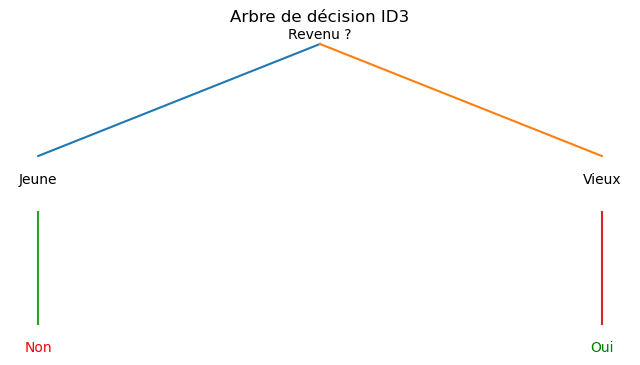

In [19]:
import numpy as np  # importation de numpy pour manipuler les tableaux et les calculs mathématiques
import matplotlib.pyplot as plt  # importation de matplotlib pour afficher les graphes et visualisations


# ====================================
# 1. DONNÉES (DATASET)
# ====================================

# on crée un attribut "Age" qui représente l'âge des clients
# Jeune = jeunes clients, Vieux = clients âgés
Age = np.array([
    "Jeune","Jeune","Jeune","Vieux",
    "Vieux","Vieux","Jeune","Vieux"
])

# on crée un deuxième attribut "Revenu" (Income)
# il représente le niveau de revenu de chaque client
Revenu = np.array([
    "Faible","Moyen","Eleve","Faible",
    "Moyen","Eleve","Moyen","Eleve"
])

# variable cible (target)
# Decision = ce que le client fait : Oui ou Non
Decision = np.array([
    "Non","Non","Oui","Non",
    "Oui","Oui","Non","Oui"
])


# ====================================
# 2. FONCTION ENTROPIE
# ====================================

# cette fonction calcule l'entropie (mesure du désordre)
# plus l'entropie est grande, plus les données sont mélangées
def entropie(y):

    # on récupère les valeurs uniques et leur nombre
    valeurs, comptes = np.unique(y, return_counts=True)

    # initialisation de l'entropie
    ent = 0

    print("---- Calcul Entropie ----")

    # boucle sur chaque classe (Oui / Non)
    for i in range(len(valeurs)):

        # calcul de la probabilité de chaque classe
        p = comptes[i] / len(y)

        # affichage de la probabilité pour compréhension
        print(f"P({valeurs[i]}) = {comptes[i]}/{len(y)} = {round(p,2)}")

        # formule de l'entropie : -p log2(p)
        ent -= p * np.log2(p)

    # affichage de l'entropie finale
    print("Entropie =", round(ent,3))

    return ent  # retour de la valeur


# ====================================
# 3. ENTROPIE TOTALE DU DATASET
# ====================================

print("\n=== ENTROPIE TOTALE ===")

# on calcule l'entropie de la variable cible (Decision)
H_total = entropie(Decision)


# ====================================
# 4. CALCUL DU GAIN POUR AGE
# ====================================

# gain = entropie totale - entropie pondérée

print("\n=== GAIN AGE ===")

# on filtre les décisions où Age = Jeune
Decision_jeune = Decision[Age == "Jeune"]
print("\nCas Jeune :")
H_jeune = entropie(Decision_jeune)

# on filtre les décisions où Age = Vieux
Decision_vieux = Decision[Age == "Vieux"]
print("\nCas Vieux :")
H_vieux = entropie(Decision_vieux)

# calcul du gain d'information pour Age
gain_age = H_total - (
    (len(Decision_jeune)/len(Decision))*H_jeune +
    (len(Decision_vieux)/len(Decision))*H_vieux
)

print("\nGain(Age) =", round(gain_age,3))


# ====================================
# 5. CALCUL DU GAIN POUR REVENU
# ====================================

print("\n=== GAIN REVENU ===")

# filtrage des données selon le revenu faible
Decision_faible = Decision[Revenu == "Faible"]
print("\nCas Faible :")
H_faible = entropie(Decision_faible)

# filtrage revenu moyen
Decision_moyen = Decision[Revenu == "Moyen"]
print("\nCas Moyen :")
H_moyen = entropie(Decision_moyen)

# filtrage revenu élevé
Decision_eleve = Decision[Revenu == "Eleve"]
print("\nCas Élevé :")
H_eleve = entropie(Decision_eleve)

# calcul du gain pour Revenu
gain_revenu = H_total - (
    (len(Decision_faible)/len(Decision))*H_faible +
    (len(Decision_moyen)/len(Decision))*H_moyen +
    (len(Decision_eleve)/len(Decision))*H_eleve
)

print("\nGain(Revenu) =", round(gain_revenu,3))


# ====================================
# 6. CHOIX FINAL DE LA RACINE
# ====================================

print("\n=== RÉSULTAT FINAL ===")

# comparaison des gains
if gain_age > gain_revenu:
    meilleur_attribut = "Age"  # Age est meilleur
else:
    meilleur_attribut = "Revenu"  # Revenu est meilleur

print(" Meilleur attribut =", meilleur_attribut)


# ====================================
# 7. VISUALISATION DE L'ARBRE
# ====================================

# création de la figure
plt.figure(figsize=(8,4))

# affichage de la racine (attribut choisi)
plt.text(0.5, 0.76, f"{meilleur_attribut} ?", ha='center')

# affichage des branches (valeurs possibles)
plt.text(0.2, 0.5, "Jeune", ha='center')
plt.text(0.8, 0.5, "Vieux", ha='center')

# affichage des feuilles (résultats finaux)
plt.text(0.2, 0.2, "Non", ha='center', color="red")
plt.text(0.8, 0.2, "Oui", ha='center', color="green")

# lignes entre les nœuds de l'arbre
plt.plot([0.5,0.2],[0.75,0.55])  # racine → gauche
plt.plot([0.5,0.8],[0.75,0.55])  # racine → droite
plt.plot([0.2,0.2],[0.45,0.25])  # branche gauche → feuille
plt.plot([0.8,0.8],[0.45,0.25])  # branche droite → feuille

# suppression des axes pour un rendu propre
plt.axis('off')

# titre du graphe
plt.title("Arbre de décision ID3")

# affichage final
plt.show()

In [20]:
#C4.5


In [21]:
# C4.5 est une amélioration de ID3 qui utilise le gain ratio au lieu du gain d’information pour éviter le biais,
#son objectif est de construire un arbre de décision plus précis et plus stable.

Entropie totale = 1.0
Gain(Age) = 0.189
Gain(Revenu) = 0.656
Gain Ratio(Age) = 0.189
Gain Ratio(Revenu) = 0.42
Meilleur attribut = Revenu


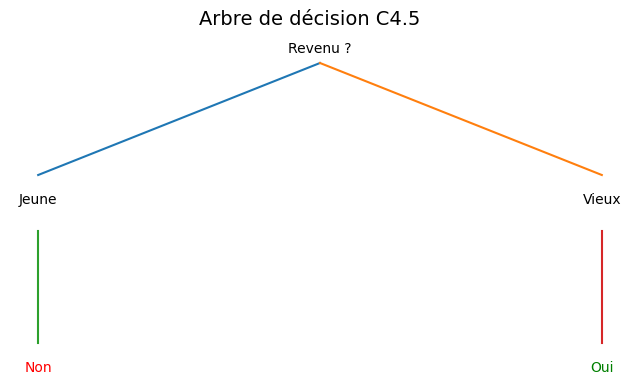

In [22]:
import numpy as np  # bibliothèque utilisée pour les calculs mathématiques et les tableaux
import matplotlib.pyplot as plt  # bibliothèque utilisée pour les graphiques


# =========================================================
# 1. DATASET (DONNÉES)
# =========================================================

# variable Age
# contient deux catégories :
# Jeune ou Vieux

Age = np.array([
    "Jeune","Jeune","Jeune","Vieux",
    "Vieux","Vieux","Jeune","Vieux"
])

# variable Revenu
# contient trois catégories :
# Faible, Moyen ou Eleve

Revenu = np.array([
    "Faible","Moyen","Eleve","Faible",
    "Moyen","Eleve","Moyen","Eleve"
])

# variable cible (classe finale)
# Oui = achat
# Non = pas d’achat

Decision = np.array([
    "Non","Non","Oui","Non",
    "Oui","Oui","Non","Oui"
])


# =========================================================
# 2. FONCTION ENTROPIE
# =========================================================

def entropie(y):

    # FORMULE :
    # H(S) = - Σ p(i) log2(p(i))
    # H(S) mesure le désordre des données
    # entropie faible  -> données pures
    # entropie élevée  -> données mélangées

    
    # récupérer les classes uniques et leur nombre
    valeurs, comptes = np.unique(y, return_counts=True)

    # initialisation de l’entropie
    ent = 0

    # boucle sur chaque classe
    for i in range(len(valeurs)):

        # calcul de la probabilité :
        # p = nombre de la classe / total

        p = comptes[i] / len(y)

        # contribution de la classe à l’entropie
        # formule :
        # - p log2(p)
        ent -= p * np.log2(p)

    # retourner l’entropie finale
    return ent


# =========================================================
# 3. ENTROPIE TOTALE
# =========================================================

# calcul de l’entropie du dataset complet
H_total = entropie(Decision)

# affichage de l’entropie totale
print("Entropie totale =", round(H_total,3))


# =========================================================
# 4. CALCUL DU GAIN POUR AGE (ID3)
# =========================================================

# séparation des décisions selon Age

Decision_jeune = Decision[Age == "Jeune"]
# décisions pour les personnes jeunes

Decision_vieux = Decision[Age == "Vieux"]
# décisions pour les personnes vieilles

# ---------------------------------------------------------
# calcul des entropies de chaque groupe
# ---------------------------------------------------------

H_jeune = entropie(Decision_jeune)
# entropie du groupe jeune

H_vieux = entropie(Decision_vieux)
# entropie du groupe vieux


# FORMULE DU GAIN :
# Gain(S,A) = H(S) - Σ (|Si| / |S|) H(Si)

# gain = entropie totale - entropie pondérée

# si le gain est grand :
# -> meilleur attribut


gain_age = H_total - (

    # proportion du groupe jeune × entropie jeune
    (len(Decision_jeune)/len(Decision))*H_jeune +

    # proportion du groupe vieux × entropie vieux
    (len(Decision_vieux)/len(Decision))*H_vieux
)

# affichage du gain
print("Gain(Age) =", round(gain_age,3))


# =========================================================
# 5. CALCUL DU GAIN POUR REVENU
# =========================================================

# séparation selon le revenu

Decision_faible = Decision[Revenu == "Faible"]
Decision_moyen = Decision[Revenu == "Moyen"]
Decision_eleve = Decision[Revenu == "Eleve"]

# calcul des entropies

H_faible = entropie(Decision_faible)
H_moyen = entropie(Decision_moyen)
H_eleve = entropie(Decision_eleve)

# calcul du gain pour Revenu

gain_revenu = H_total - (

    # proportion faible × entropie faible
    (len(Decision_faible)/len(Decision))*H_faible +

    # proportion moyen × entropie moyen
    (len(Decision_moyen)/len(Decision))*H_moyen +

    # proportion élevé × entropie élevé
    (len(Decision_eleve)/len(Decision))*H_eleve
)

# affichage du gain revenu
print("Gain(Revenu) =", round(gain_revenu,3))


# =========================================================
# 6. SPLIT INFO (C4.5)
# =========================================================

def split_info(groupes, total):

    # FORMULE :
    # SI(A) = - Σ (|Si|/|S|) log2(|Si|/|S|)
   
    # mesure la quantité de division des données
    # utilisée dans C4.5

    si = 0

    # boucle sur tous les groupes
    for g in groupes:

        # calcul de la proportion du groupe
        p = len(g) / total

        # éviter log(0)
        if p > 0:

            # calcul du split info
            si -= p * np.log2(p)

    return si


# =========================================================
# 7. GAIN RATIO POUR AGE
# =========================================================

# calcul du split info pour Age
SI_age = split_info([Decision_jeune, Decision_vieux], len(Decision))

# FORMULE :
# GainRatio(A) = Gain(A) / SplitInfo(A)

gain_ratio_age = gain_age / SI_age

# affichage
print("Gain Ratio(Age) =", round(gain_ratio_age,3))


# =========================================================
# 8. GAIN RATIO POUR REVENU
# =========================================================

# calcul du split info pour Revenu
SI_revenu = split_info(
    [Decision_faible, Decision_moyen, Decision_eleve],
    len(Decision)
)

# calcul du gain ratio
gain_ratio_revenu = gain_revenu / SI_revenu

# affichage
print("Gain Ratio(Revenu) =", round(gain_ratio_revenu,3))


# =========================================================
# 9. CHOIX FINAL
# =========================================================

# comparaison des gain ratios

if gain_ratio_age > gain_ratio_revenu:

    # Age devient le meilleur attribut
    meilleur_attribut = "Age"

else:

    # sinon Revenu devient le meilleur attribut
    meilleur_attribut = "Revenu"

# affichage du meilleur attribut
print("Meilleur attribut =", meilleur_attribut)


# =========================================================
# 10. VISUALISATION DE L’ARBRE
# =========================================================

# création de la figure
plt.figure(figsize=(8,4))

# titre principal
plt.suptitle("Arbre de décision C4.5", fontsize=14)

# noeud principal
plt.text(0.5, 0.77, f"{meilleur_attribut} ?", ha='center')

# branches
plt.text(0.2, 0.5, "Jeune", ha='center')
plt.text(0.8, 0.5, "Vieux", ha='center')

# feuilles finales
plt.text(0.2, 0.2, "Non", ha='center', color="red")
plt.text(0.8, 0.2, "Oui", ha='center', color="green")

# lignes de liaison
plt.plot([0.5,0.2],[0.75,0.55])
plt.plot([0.5,0.8],[0.75,0.55])

plt.plot([0.2,0.2],[0.45,0.25])
plt.plot([0.8,0.8],[0.45,0.25])

# suppression des axes
plt.axis('off')

# affichage final
plt.show()

In [23]:
#CART


In [24]:
# CART est un algorithme d’arbre de décision qui peut être utilisé pour la classification et la régression,
#il utilise l’indice de Gini pour construire les splits, son objectif est de créer un modèle robuste et efficace.


--- Calcul Gini ---
P(Non) = 4/8 = 0.5
p² = 0.25
P(Oui) = 4/8 = 0.5
p² = 0.25
Gini = 0.5

--- Groupe JEUNE ---

--- Calcul Gini ---
P(Non) = 3/4 = 0.75
p² = 0.562
P(Oui) = 1/4 = 0.25
p² = 0.062
Gini = 0.375

--- Groupe VIEUX ---

--- Calcul Gini ---
P(Non) = 1/4 = 0.25
p² = 0.062
P(Oui) = 3/4 = 0.75
p² = 0.562
Gini = 0.375

Gini(Age) = 0.375

--- Groupe FAIBLE ---

--- Calcul Gini ---
P(Non) = 2/2 = 1.0
p² = 1.0
Gini = 0.0

--- Groupe MOYEN ---

--- Calcul Gini ---
P(Non) = 2/3 = 0.67
p² = 0.444
P(Oui) = 1/3 = 0.33
p² = 0.111
Gini = 0.444

--- Groupe ELEVE ---

--- Calcul Gini ---
P(Oui) = 3/3 = 1.0
p² = 1.0
Gini = 0.0

Gini(Revenu) = 0.167

--- COMPARAISON ---
Gini Age    = 0.375
Gini Revenu = 0.167

Meilleur attribut (CART) = Revenu


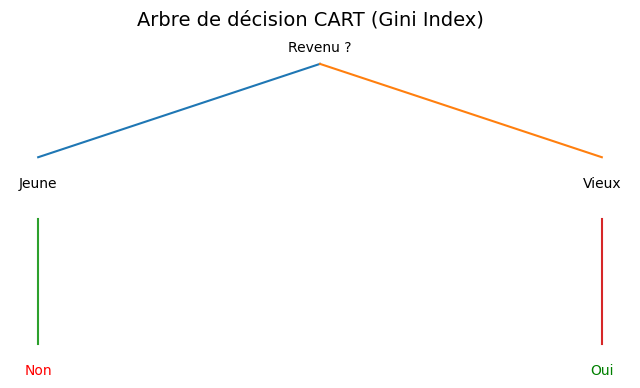

In [25]:
import numpy as np
import matplotlib.pyplot as plt


# ====================================
# 1. DATASET
# ====================================

# Age : attribut (feature) qui représente l'âge du client
Age = np.array([
    "Jeune","Jeune","Jeune","Vieux",
    "Vieux","Vieux","Jeune","Vieux"
])

# Revenu : autre attribut (feature)
Revenu = np.array([
    "Faible","Moyen","Eleve","Faible",
    "Moyen","Eleve","Moyen","Eleve"
])

# Decision : variable cible (target)
# Oui = achat, Non = pas d’achat
Decision = np.array([
    "Non","Non","Oui","Non",
    "Oui","Oui","Non","Oui"
])


# ====================================
# 2. FONCTION GINI
# ====================================

def gini(y):

    # Gini(S) = 1 - Σ p(i)^2
    # mesure l’impureté (mix des classes)

    valeurs, comptes = np.unique(y, return_counts=True)

    g = 1  # valeur initiale = 1 (maximum d'impureté)

    print("\n--- Calcul Gini ---")

    for i in range(len(valeurs)):

        # p(i) = probabilité de chaque classe
        p = comptes[i] / len(y)

        # affichage des calculs
        print(f"P({valeurs[i]}) = {comptes[i]}/{len(y)} = {round(p,2)}")
        print(f"p² = {round(p**2,3)}")

        # soustraction dans la formule Gini
        g -= p ** 2

    print("Gini =", round(g,3))
    return g


# ====================================
# 3. GINI GLOBAL
# ====================================

# calcul de l'impureté totale avant split
G_total = gini(Decision)


# ====================================
# 4. SPLIT SUR AGE
# ====================================

# on divise les données selon Age
Decision_jeune = Decision[Age == "Jeune"]
Decision_vieux = Decision[Age == "Vieux"]

# calcul Gini pour chaque sous-groupe
print("\n--- Groupe JEUNE ---")
G_jeune = gini(Decision_jeune)

print("\n--- Groupe VIEUX ---")
G_vieux = gini(Decision_vieux)

# Gini pondéré après split
gini_age = (
    (len(Decision_jeune)/len(Decision)) * G_jeune +
    (len(Decision_vieux)/len(Decision)) * G_vieux
)

print("\nGini(Age) =", round(gini_age,3))


# ====================================
# 5. SPLIT SUR REVENU
# ====================================

# séparation selon Revenu
Decision_faible = Decision[Revenu == "Faible"]
Decision_moyen = Decision[Revenu == "Moyen"]
Decision_eleve = Decision[Revenu == "Eleve"]

# Gini de chaque groupe
print("\n--- Groupe FAIBLE ---")
G_faible = gini(Decision_faible)

print("\n--- Groupe MOYEN ---")
G_moyen = gini(Decision_moyen)

print("\n--- Groupe ELEVE ---")
G_eleve = gini(Decision_eleve)

# Gini pondéré pour Revenu
gini_revenu = (
    (len(Decision_faible)/len(Decision)) * G_faible +
    (len(Decision_moyen)/len(Decision)) * G_moyen +
    (len(Decision_eleve)/len(Decision)) * G_eleve
)

print("\nGini(Revenu) =", round(gini_revenu,3))


# ====================================
# 6. CHOIX CART
# ====================================

# règle CART :
# on choisit l’attribut avec le PLUS PETIT Gini

print("\n--- COMPARAISON ---")
print("Gini Age    =", round(gini_age,3))
print("Gini Revenu =", round(gini_revenu,3))

if gini_age < gini_revenu:
    best = "Age"
else:
    best = "Revenu"

print("\nMeilleur attribut (CART) =", best)


# ====================================
# 7. VISUALISATION ARBRE
# ====================================

plt.figure(figsize=(8,4))

# titre principal du graphe
plt.suptitle("Arbre de décision CART (Gini Index)", fontsize=14)

# racine (meilleur attribut choisi)
plt.text(0.5, 0.72, f"{best} ?", ha='center')

# branches de l’arbre
plt.text(0.2, 0.5, "Jeune", ha='center')
plt.text(0.8, 0.5, "Vieux", ha='center')

# feuilles (résultat final)
plt.text(0.2, 0.2, "Non", ha='center', color="red")
plt.text(0.8, 0.2, "Oui", ha='center', color="green")

# lignes de connexion entre noeuds
plt.plot([0.5,0.2],[0.7,0.55])
plt.plot([0.5,0.8],[0.7,0.55])
plt.plot([0.2,0.2],[0.45,0.25])
plt.plot([0.8,0.8],[0.45,0.25])

# cacher les axes pour un rendu propre
plt.axis('off')
plt.show()